# Compare CNN: clean vs noise features

Evaluate the **fixed training-domain CNN** on clean and noise-mixed cross-domain packs (**vivo / thinkpad / flow / thinkpad-2 / flow-2 / thinkpad-2 / flow-2**).

- Training features are **not** mixed; model is the baseline `model-bn-c64-c128-c256-c256-d256.keras`.
- **flow** = original ROG Flow evaluation set (`evaluations/test-all`, linked as `datasets/flow` + `features/flow.npz`).
- Predictions and metrics are **cached** under `cnn-compare-results/` so a crash mid-run can resume.
- Set `FORCE_REEVAL = True` to recompute everything.

## Config

In [1]:
from os import path
import pandas as pd
from IPython.display import display

# --- paths ---
FEATURES_DIR = path.normpath("../../features")
MODEL_PATH = path.normpath("../../models/model-bn-c64-c128-c256-c256-d256.keras")
RESULTS_DIR = path.normpath("./cnn-compare-results")
CACHE_DIR = path.join(RESULTS_DIR, "cache")
METRICS_DIR = path.join(RESULTS_DIR, "metrics")
SUMMARY_PATH = path.join(RESULTS_DIR, "summary.csv")
PERCLASS_PATH = path.join(RESULTS_DIR, "perclass_comparison.csv")
PROGRESS_PATH = path.join(RESULTS_DIR, "progress.csv")

# Canonical class order from training labels
TRAINING_FEATURES = path.join(FEATURES_DIR, "training.npz")

# Eval packs: clean + noise for each cross-domain set
# flow = ROG Flow paper/eval pack (test-all)
EVAL_SETS = [
    {"name": "vivo_clean", "domain": "vivo", "variant": "clean",
     "features": "vivo.npz"},
    {"name": "vivo_noise", "domain": "vivo", "variant": "noise",
     "features": "vivo-noise-interior_domestic.npz"},
    {"name": "thinkpad_clean", "domain": "thinkpad", "variant": "clean",
     "features": "thinkpad.npz"},
    {"name": "thinkpad_noise", "domain": "thinkpad", "variant": "noise",
     "features": "thinkpad-noise-interior_domestic.npz"},
    {"name": "flow_clean", "domain": "flow", "variant": "clean",
     "features": "flow.npz"},
    {"name": "flow_noise", "domain": "flow", "variant": "noise",
     "features": "flow-noise-interior_domestic.npz"},
    {"name": "thinkpad-2_clean", "domain": "thinkpad-2", "variant": "clean",
     "features": "thinkpad-2.npz"},
    {"name": "thinkpad-2_noise", "domain": "thinkpad-2", "variant": "noise",
     "features": "thinkpad-2-noise-interior_domestic.npz"},
    {"name": "flow-2_clean", "domain": "flow-2", "variant": "clean",
     "features": "flow-2.npz"},
    {"name": "flow-2_noise", "domain": "flow-2", "variant": "noise",
     "features": "flow-2-noise-interior_domestic.npz"},
]

FORCE_REEVAL = False  # True = ignore caches and re-predict
BATCH_SIZE = 16
RANDOM_STATE = 42
TF_CPP_MIN_LOG_LEVEL = "3"

config_df = pd.DataFrame(
    [
        {"key": "model_path", "value": MODEL_PATH},
        {"key": "results_dir", "value": RESULTS_DIR},
        {"key": "force_reeval", "value": FORCE_REEVAL},
        {"key": "batch_size", "value": BATCH_SIZE},
        {"key": "n_eval_sets", "value": len(EVAL_SETS)},
    ]
).set_index("key")
eval_sets_df = pd.DataFrame(EVAL_SETS)
display(config_df)
display(eval_sets_df)

,value
key,
model_path,../../models/model-bn-c64-c128-c256-c256-d256....
results_dir,cnn-compare-results
force_reeval,False
batch_size,16
n_eval_sets,10


,name,domain,variant,features
0,vivo_clean,vivo,clean,vivo.npz
1,vivo_noise,vivo,noise,vivo-noise-interior_domestic.npz
2,thinkpad_clean,thinkpad,clean,thinkpad.npz
3,thinkpad_noise,thinkpad,noise,thinkpad-noise-interior_domestic.npz
4,flow_clean,flow,clean,flow.npz
5,flow_noise,flow,noise,flow-noise-interior_domestic.npz
6,thinkpad-2_clean,thinkpad-2,clean,thinkpad-2.npz
7,thinkpad-2_noise,thinkpad-2,noise,thinkpad-2-noise-interior_domestic.npz
8,flow-2_clean,flow-2,clean,flow-2.npz
9,flow-2_noise,flow-2,noise,flow-2-noise-interior_domestic.npz


## Setup

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = TF_CPP_MIN_LOG_LEVEL
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

import random
import numpy as np
import tensorflow as tf
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder
from os import makedirs, path, remove

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as exc:
        pass

makedirs(CACHE_DIR, exist_ok=True)
makedirs(METRICS_DIR, exist_ok=True)

setup_df = pd.DataFrame(
    [{
        "tensorflow": tf.__version__,
        "gpus": str(gpus),
        "cache_dir": CACHE_DIR,
        "metrics_dir": METRICS_DIR,
    }]
)
display(setup_df)

,tensorflow,gpus,cache_dir,metrics_dir
0,2.15.0,"[PhysicalDevice(name='/physical_device:GPU:0',...",cnn-compare-results/cache,cnn-compare-results/metrics


## Helpers (cache + metrics)

In [3]:
def cache_path(name):
    return path.join(CACHE_DIR, f"{name}.npz")


def metrics_path(name):
    return path.join(METRICS_DIR, f"{name}.csv")


def load_class_names():
    with np.load(TRAINING_FEATURES, allow_pickle=True) as train:
        return np.sort(np.unique(np.asarray(train["labels"]).astype(str)))


def compute_metrics(y_true, y_pred, class_names, name, domain, variant):
    acc = accuracy_score(y_true, y_pred)
    p_m, r_m, f_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    summary = {
        "name": name,
        "domain": domain,
        "variant": variant,
        "n_samples": int(len(y_true)),
        "n_classes": int(len(class_names)),
        "accuracy": float(acc),
        "macro_precision": float(p_m),
        "macro_recall": float(r_m),
        "macro_f1": float(f_m),
        "weighted_precision": float(p_w),
        "weighted_recall": float(r_w),
        "weighted_f1": float(f_w),
    }
    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=list(class_names),
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    report_df.insert(0, "name", name)
    report_df.insert(1, "domain", domain)
    report_df.insert(2, "variant", variant)
    return summary, report_df


def evaluate_one(spec, model, label_encoder, class_names):
    """Predict + metrics for one pack. Uses cache when available."""
    name = spec["name"]
    feat_path = path.join(FEATURES_DIR, spec["features"])
    cpath = cache_path(name)
    mpath = metrics_path(name)

    if path.isfile(cpath) and path.isfile(mpath) and not FORCE_REEVAL:
        cached = np.load(cpath, allow_pickle=True)
        metrics_df = pd.read_csv(mpath)
        summary = metrics_df.iloc[0].to_dict()
        return {
            "status": "cache_hit",
            "summary": summary,
            "y_true": cached["y_true"],
            "y_pred": cached["y_pred"],
            "labels": cached["labels"].astype(str),
            "class_names": class_names,
            "cache_path": cpath,
            "metrics_path": mpath,
        }

    if not path.isfile(feat_path):
        raise FileNotFoundError(feat_path)

    with np.load(feat_path, allow_pickle=True) as data:
        features = data["features"]
        labels = np.asarray(data["labels"]).astype(str)

    unknown = sorted(set(labels) - set(class_names))
    if unknown:
        raise ValueError(f"{name}: labels not in training classes: {unknown[:5]}")

    y_true = label_encoder.transform(labels)
    x = features
    if x.ndim == 3:
        x = np.expand_dims(x, axis=-1)
    x = x.astype(np.float32, copy=False)

    proba = model.predict(x, batch_size=BATCH_SIZE, verbose=1)
    y_pred = np.argmax(proba, axis=1)

    summary, report_df = compute_metrics(
        y_true, y_pred, class_names, name, spec["domain"], spec["variant"]
    )

    # atomic-ish write: save cache then metrics
    np.savez_compressed(
        cpath,
        y_true=y_true.astype(np.int32),
        y_pred=y_pred.astype(np.int32),
        proba=proba.astype(np.float32),
        labels=labels.astype(str),
        class_names=class_names.astype(str),
        features_path=np.asarray(feat_path),
        model_path=np.asarray(MODEL_PATH),
        domain=np.asarray(spec["domain"]),
        variant=np.asarray(spec["variant"]),
    )
    metrics_df = pd.DataFrame([summary])
    metrics_df.to_csv(mpath, index=False)
    report_df.to_csv(path.join(METRICS_DIR, f"{name}_report.csv"))

    return {
        "status": "computed",
        "summary": summary,
        "y_true": y_true,
        "y_pred": y_pred,
        "labels": labels,
        "class_names": class_names,
        "cache_path": cpath,
        "metrics_path": mpath,
    }


def write_progress(rows):
    pd.DataFrame(rows).to_csv(PROGRESS_PATH, index=False)


display(pd.DataFrame([{"helpers": "ready"}]))

,helpers
0,ready


## Evaluate (with resume)

In [4]:
from sklearn.preprocessing import LabelEncoder

assert path.isfile(MODEL_PATH), f"Missing model: {MODEL_PATH}"
assert path.isfile(TRAINING_FEATURES), f"Missing training features: {TRAINING_FEATURES}"
for spec in EVAL_SETS:
    fp = path.join(FEATURES_DIR, spec["features"])
    assert path.isfile(fp), f"Missing features: {fp}"

tf.keras.backend.clear_session()
model = tf.keras.models.load_model(MODEL_PATH)
class_names = load_class_names()
label_encoder = LabelEncoder()
label_encoder.fit(class_names)

model_df = pd.DataFrame(
    [{
        "model_path": MODEL_PATH,
        "input_shape": model.input_shape,
        "output_shape": model.output_shape,
        "n_classes": len(class_names),
    }]
)
display(model_df)

run_results = []
progress_rows = []

for spec in EVAL_SETS:
    result = evaluate_one(spec, model, label_encoder, class_names)
    run_results.append(result)
    row = dict(result["summary"])
    row["status"] = result["status"]
    row["cache_path"] = result["cache_path"]
    progress_rows.append(row)
    write_progress(progress_rows)  # checkpoint after each pack
    display(pd.DataFrame([row])[[
        "name", "domain", "variant", "status", "n_samples",
        "accuracy", "macro_f1", "weighted_f1",
    ]])

progress_df = pd.DataFrame(progress_rows)
display(progress_df[[
    "name", "domain", "variant", "status", "n_samples",
    "accuracy", "macro_precision", "macro_recall", "macro_f1",
]])

,model_path,input_shape,output_shape,n_classes
0,../../models/model-bn-c64-c128-c256-c256-d256....,"(None, 216, 188, 1)","(None, 36)",36


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,vivo_clean,vivo,clean,cache_hit,1440,0.945833,0.937388,0.937388


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,vivo_noise,vivo,noise,cache_hit,1440,0.910417,0.898828,0.898828


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,thinkpad_clean,thinkpad,clean,cache_hit,1440,0.994444,0.994428,0.994428


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,thinkpad_noise,thinkpad,noise,cache_hit,1440,0.959722,0.96044,0.96044


...

,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,thinkpad-2_clean,thinkpad-2,clean,cache_hit,1440,0.885417,0.855961,0.855961


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,thinkpad-2_noise,thinkpad-2,noise,cache_hit,1440,0.836806,0.813397,0.813397


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,flow-2_clean,flow-2,clean,cache_hit,1440,0.874306,0.84017,0.84017


,name,domain,variant,status,n_samples,accuracy,macro_f1,weighted_f1
0,flow-2_noise,flow-2,noise,cache_hit,1440,0.841667,0.817305,0.817305


,name,domain,variant,status,n_samples,accuracy,macro_precision,macro_recall,macro_f1
0,vivo_clean,vivo,clean,cache_hit,1440,0.945833,0.949536,0.945833,0.937388
1,vivo_noise,vivo,noise,cache_hit,1440,0.910417,0.911559,0.910417,0.898828
2,thinkpad_clean,thinkpad,clean,cache_hit,1440,0.994444,0.994976,0.994444,0.994428
3,thinkpad_noise,thinkpad,noise,cache_hit,1440,0.959722,0.967151,0.959722,0.960440
4,flow_clean,flow,clean,cache_hit,1440,0.943750,0.964463,0.943750,0.935195
5,flow_noise,flow,noise,cache_hit,1440,0.935417,0.945419,0.935417,0.926245
6,thinkpad-2_clean,thinkpad-2,clean,cache_hit,1440,0.885417,0.848812,0.885417,0.855961
7,thinkpad-2_noise,thinkpad-2,noise,cache_hit,1440,0.836806,0.858093,0.836806,0.813397
8,flow-2_clean,flow-2,clean,cache_hit,1440,0.874306,0.848498,0.874306,0.840170
9,flow-2_noise,flow-2,noise,cache_hit,1440,0.841667,0.885000,0.841667,0.817305


## Comparison tables

In [5]:
# Rebuild summary from caches (safe if re-run without re-predict)
rows = []
for spec in EVAL_SETS:
    mpath = metrics_path(spec["name"])
    if not path.isfile(mpath):
        continue
    df = pd.read_csv(mpath)
    rows.append(df.iloc[0].to_dict())

summary_df = pd.DataFrame(rows)
summary_df.to_csv(SUMMARY_PATH, index=False)

# Wide comparison: clean vs noise per domain
wide = summary_df.pivot(index="domain", columns="variant", values=[
    "accuracy", "macro_f1", "weighted_f1", "n_samples"
])
# Flatten multiindex columns for readability
wide.columns = [f"{metric}_{variant}" for metric, variant in wide.columns]
wide = wide.reset_index()

# Deltas (noise - clean): negative = noise hurts
for metric in ["accuracy", "macro_f1", "weighted_f1"]:
    ccol, ncol = f"{metric}_clean", f"{metric}_noise"
    if ccol in wide.columns and ncol in wide.columns:
        wide[f"delta_{metric}"] = wide[ncol] - wide[ccol]

display(summary_df.sort_values(["domain", "variant"]).reset_index(drop=True))
display(wide)

wide.to_csv(path.join(RESULTS_DIR, "summary_wide.csv"), index=False)
display(pd.DataFrame([{"summary_path": SUMMARY_PATH, "wide_path": path.join(RESULTS_DIR, "summary_wide.csv")}]))

,name,domain,variant,n_samples,n_classes,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,flow_clean,flow,clean,1440,36,0.943750,0.964463,0.943750,0.935195,0.964463,0.943750,0.935195
1,flow_noise,flow,noise,1440,36,0.935417,0.945419,0.935417,0.926245,0.945419,0.935417,0.926245
2,flow-2_clean,flow-2,clean,1440,36,0.874306,0.848498,0.874306,0.840170,0.848498,0.874306,0.840170
3,flow-2_noise,flow-2,noise,1440,36,0.841667,0.885000,0.841667,0.817305,0.885000,0.841667,0.817305
4,thinkpad_clean,thinkpad,clean,1440,36,0.994444,0.994976,0.994444,0.994428,0.994976,0.994444,0.994428
5,thinkpad_noise,thinkpad,noise,1440,36,0.959722,0.967151,0.959722,0.960440,0.967151,0.959722,0.960440
6,thinkpad-2_clean,thinkpad-2,clean,1440,36,0.885417,0.848812,0.885417,0.855961,0.848812,0.885417,0.855961
7,thinkpad-2_noise,thinkpad-2,noise,1440,36,0.836806,0.858093,0.836806,0.813397,0.858093,0.836806,0.813397
8,vivo_clean,vivo,clean,1440,36,0.945833,0.949536,0.945833,0.937388,0.949536,0.945833,0.937388
9,vivo_noise,vivo,noise,1440,36,0.910417,0.911559,0.910417,0.898828,0.911559,0.910417,0.898828


,domain,accuracy_clean,accuracy_noise,macro_f1_clean,macro_f1_noise,weighted_f1_clean,weighted_f1_noise,n_samples_clean,n_samples_noise,delta_accuracy,delta_macro_f1,delta_weighted_f1
0,flow,0.943750,0.935417,0.935195,0.926245,0.935195,0.926245,1440.0,1440.0,-0.008333,-0.008950,-0.008950
1,flow-2,0.874306,0.841667,0.840170,0.817305,0.840170,0.817305,1440.0,1440.0,-0.032639,-0.022865,-0.022865
2,thinkpad,0.994444,0.959722,0.994428,0.960440,0.994428,0.960440,1440.0,1440.0,-0.034722,-0.033988,-0.033988
3,thinkpad-2,0.885417,0.836806,0.855961,0.813397,0.855961,0.813397,1440.0,1440.0,-0.048611,-0.042564,-0.042564
4,vivo,0.945833,0.910417,0.937388,0.898828,0.937388,0.898828,1440.0,1440.0,-0.035417,-0.038559,-0.038559


,summary_path,wide_path
0,cnn-compare-results/summary.csv,cnn-compare-results/summary_wide.csv


## Per-class clean vs noise

In [6]:
from sklearn.metrics import recall_score

perclass_frames = []
for spec in EVAL_SETS:
    cpath = cache_path(spec["name"])
    if not path.isfile(cpath):
        continue
    cached = np.load(cpath, allow_pickle=True)
    y_true = cached["y_true"]
    y_pred = cached["y_pred"]
    names = cached["class_names"].astype(str)
    recalls = recall_score(
        y_true, y_pred, labels=np.arange(len(names)), average=None, zero_division=0
    )
    perclass_frames.append(pd.DataFrame({
        "domain": spec["domain"],
        "variant": spec["variant"],
        "class": names,
        "recall": recalls,
        "support": np.bincount(y_true, minlength=len(names)),
    }))

perclass_long = pd.concat(perclass_frames, ignore_index=True)

# Pivot to clean/noise columns per domain+class
perclass_wide = perclass_long.pivot_table(
    index=["domain", "class"],
    columns="variant",
    values="recall",
    aggfunc="first",
).reset_index()
perclass_wide.columns.name = None
if "clean" in perclass_wide.columns and "noise" in perclass_wide.columns:
    perclass_wide["delta_recall"] = perclass_wide["noise"] - perclass_wide["clean"]

perclass_wide.to_csv(PERCLASS_PATH, index=False)

# Show largest drops under noise (most hurt classes)
for domain in sorted(perclass_wide["domain"].unique()):
    sub = perclass_wide[perclass_wide["domain"] == domain].copy()
    if "delta_recall" in sub.columns:
        sub = sub.sort_values("delta_recall").head(10)
    display(pd.DataFrame([{"domain": domain, "note": "top-10 largest recall drops (noise − clean)"}]))
    display(sub.reset_index(drop=True))

display(pd.DataFrame([{"perclass_path": PERCLASS_PATH, "n_rows": len(perclass_wide)}]))

,domain,note
0,flow,top-10 largest recall drops (noise − clean)


,domain,class,clean,noise,delta_recall
0,flow,C_major_4,1.0,0.825,-0.175
1,flow,F#_minor_4,1.0,0.875,-0.125
2,flow,G_minor_4,1.0,0.900,-0.100
3,flow,D#_diminished_4,1.0,0.900,-0.100
4,flow,D_major_4,1.0,0.950,-0.050
5,flow,F#_diminished_4,1.0,0.950,-0.050
6,flow,G_major_4,1.0,0.950,-0.050
7,flow,C#_minor_4,1.0,0.950,-0.050
8,flow,E_major_4,1.0,0.950,-0.050
9,flow,F_major_4,1.0,0.975,-0.025


,domain,note
0,flow-2,top-10 largest recall drops (noise − clean)


,domain,class,clean,noise,delta_recall
0,flow-2,C_major_4,1.000,0.725,-0.275
1,flow-2,G#_minor_4,0.875,0.625,-0.250
2,flow-2,D_major_4,1.000,0.800,-0.200
3,flow-2,D#_minor_4,1.000,0.875,-0.125
4,flow-2,E_minor_4,1.000,0.900,-0.100
5,flow-2,A_diminished_4,1.000,0.925,-0.075
6,flow-2,F#_major_4,1.000,0.950,-0.050
7,flow-2,F_diminished_4,1.000,0.950,-0.050
8,flow-2,G#_major_4,1.000,0.950,-0.050
9,flow-2,A_major_4,1.000,0.950,-0.050


,domain,note
0,thinkpad,top-10 largest recall drops (noise − clean)


...

,domain,note
0,thinkpad-2,top-10 largest recall drops (noise − clean)


,domain,class,clean,noise,delta_recall
0,thinkpad-2,C_major_4,0.975,0.675,-0.300
1,thinkpad-2,D_major_4,1.000,0.725,-0.275
2,thinkpad-2,A#_major_4,1.000,0.750,-0.250
3,thinkpad-2,B_major_4,0.750,0.550,-0.200
4,thinkpad-2,G_major_4,1.000,0.850,-0.150
5,thinkpad-2,A#_diminished_4,0.525,0.425,-0.100
6,thinkpad-2,D#_minor_4,1.000,0.900,-0.100
7,thinkpad-2,A_major_4,1.000,0.900,-0.100
8,thinkpad-2,D#_major_4,1.000,0.925,-0.075
9,thinkpad-2,B_minor_4,1.000,0.950,-0.050


,domain,note
0,vivo,top-10 largest recall drops (noise − clean)


,domain,class,clean,noise,delta_recall
0,vivo,G_minor_4,0.825,0.625,-0.200
1,vivo,B_major_4,1.000,0.850,-0.150
2,vivo,D_minor_4,1.000,0.900,-0.100
3,vivo,G_diminished_4,0.975,0.900,-0.075
4,vivo,F_major_4,1.000,0.925,-0.075
5,vivo,B_minor_4,0.975,0.900,-0.075
6,vivo,F_diminished_4,1.000,0.950,-0.050
7,vivo,D#_major_4,1.000,0.950,-0.050
8,vivo,C#_major_4,1.000,0.950,-0.050
9,vivo,D#_minor_4,1.000,0.950,-0.050


,perclass_path,n_rows
0,cnn-compare-results/perclass_comparison.csv,180


## Summary bar chart

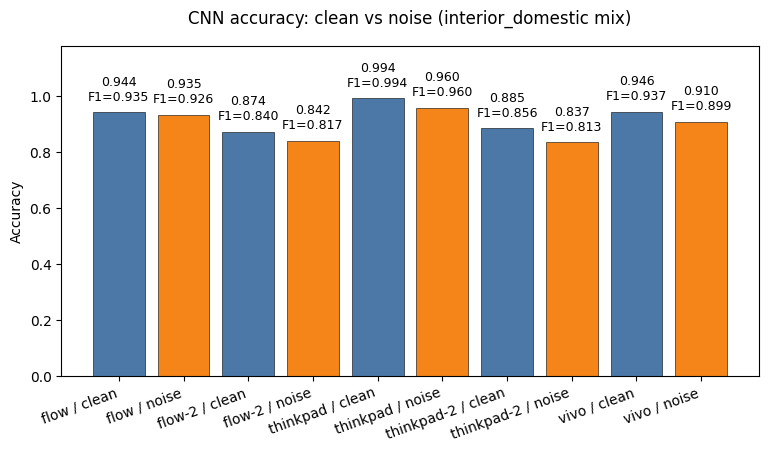

,bar_chart
0,cnn-compare-results/accuracy_clean_vs_noise.png


In [7]:
import matplotlib.pyplot as plt

plot_df = summary_df.copy()
plot_df["label"] = plot_df["domain"] + " / " + plot_df["variant"]
plot_df = plot_df.sort_values(["domain", "variant"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
colors = ["#4C78A8" if v == "clean" else "#F58518" for v in plot_df["variant"]]
bars = ax.bar(x, plot_df["accuracy"], color=colors, edgecolor="black", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=20, ha="right")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.18)  # headroom so value labels don't hit the title
ax.set_title(
    "CNN accuracy: clean vs noise (interior_domestic mix)",
    pad=16,
)

for i, (acc, f1) in enumerate(zip(plot_df["accuracy"], plot_df["macro_f1"])):
    ax.text(
        i,
        acc + 0.03,
        f"{acc:.3f}\nF1={f1:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.subplots_adjust(top=0.88, bottom=0.22)
bar_path = path.join(RESULTS_DIR, "accuracy_clean_vs_noise.png")
fig.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame([{"bar_chart": bar_path}]))

## Confusion matrices

One matrix per eval pack (clean and noise). Saved under `cnn-compare-results/confusion/`.

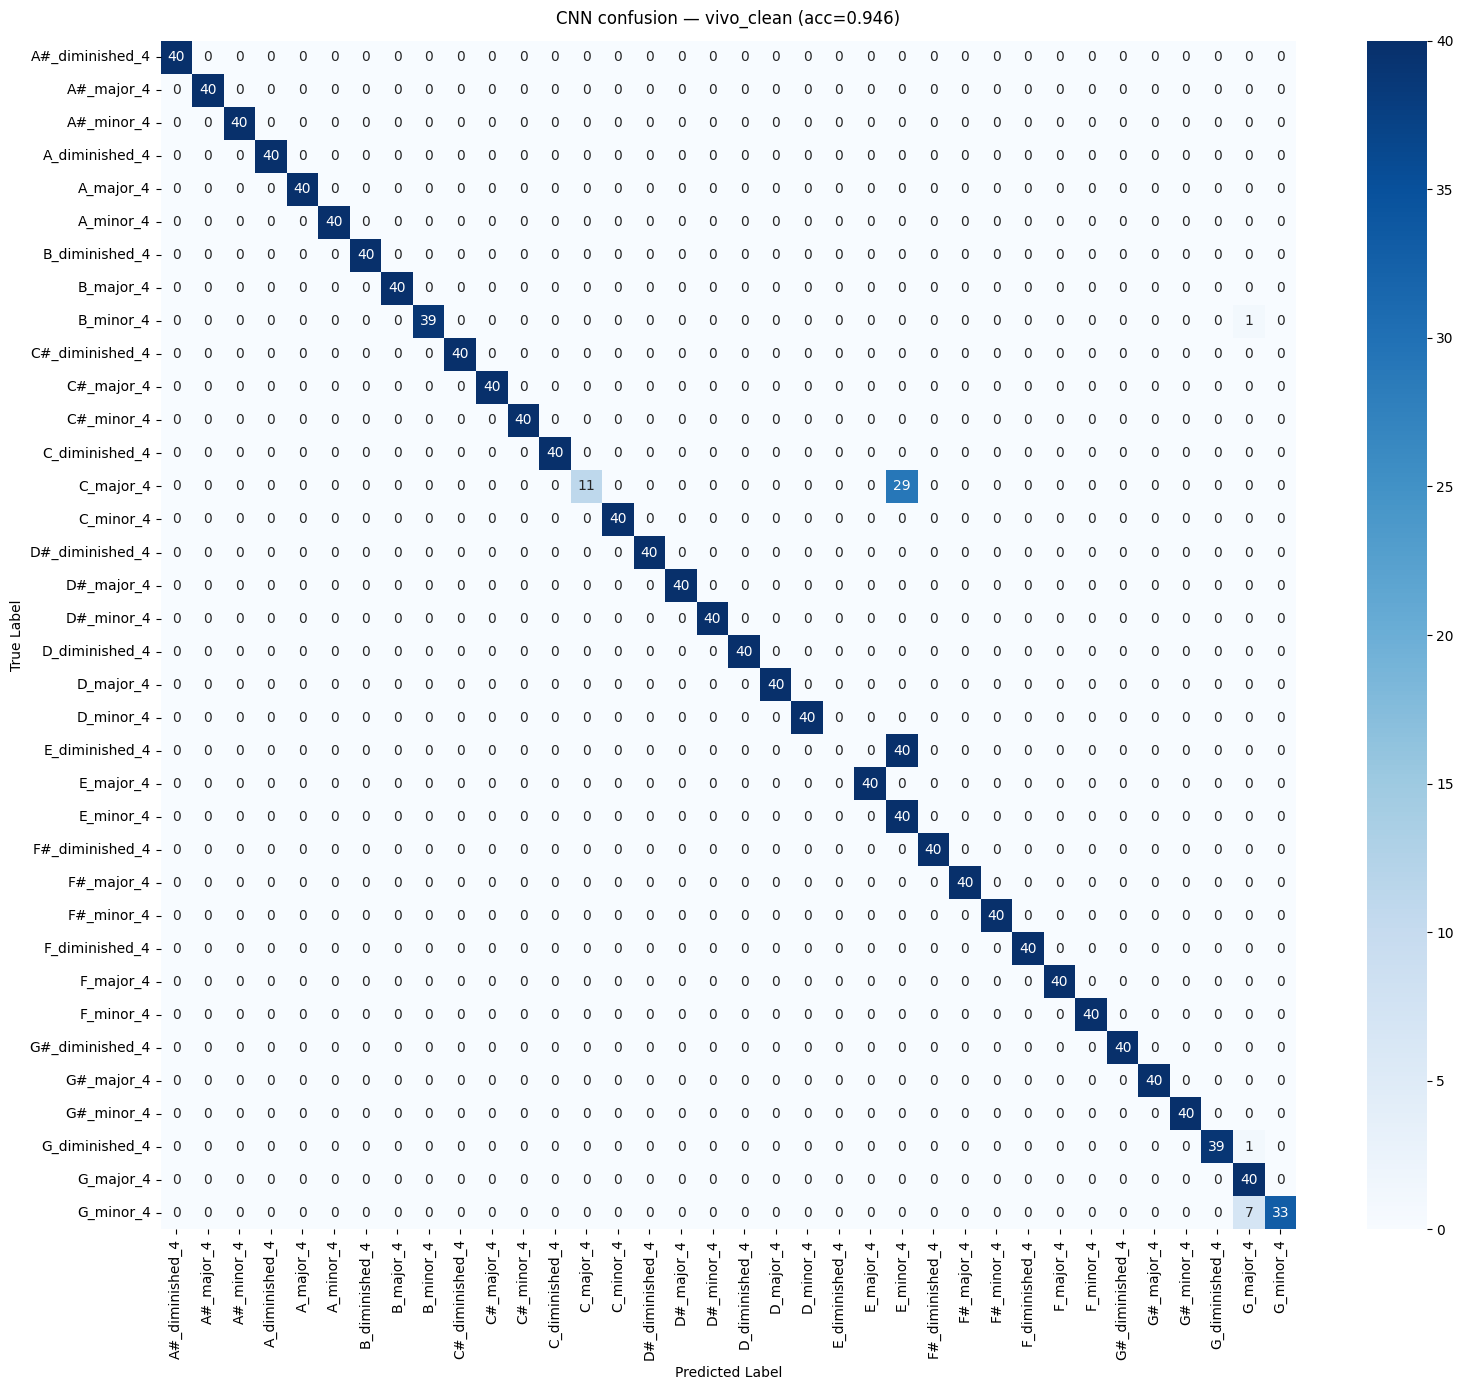

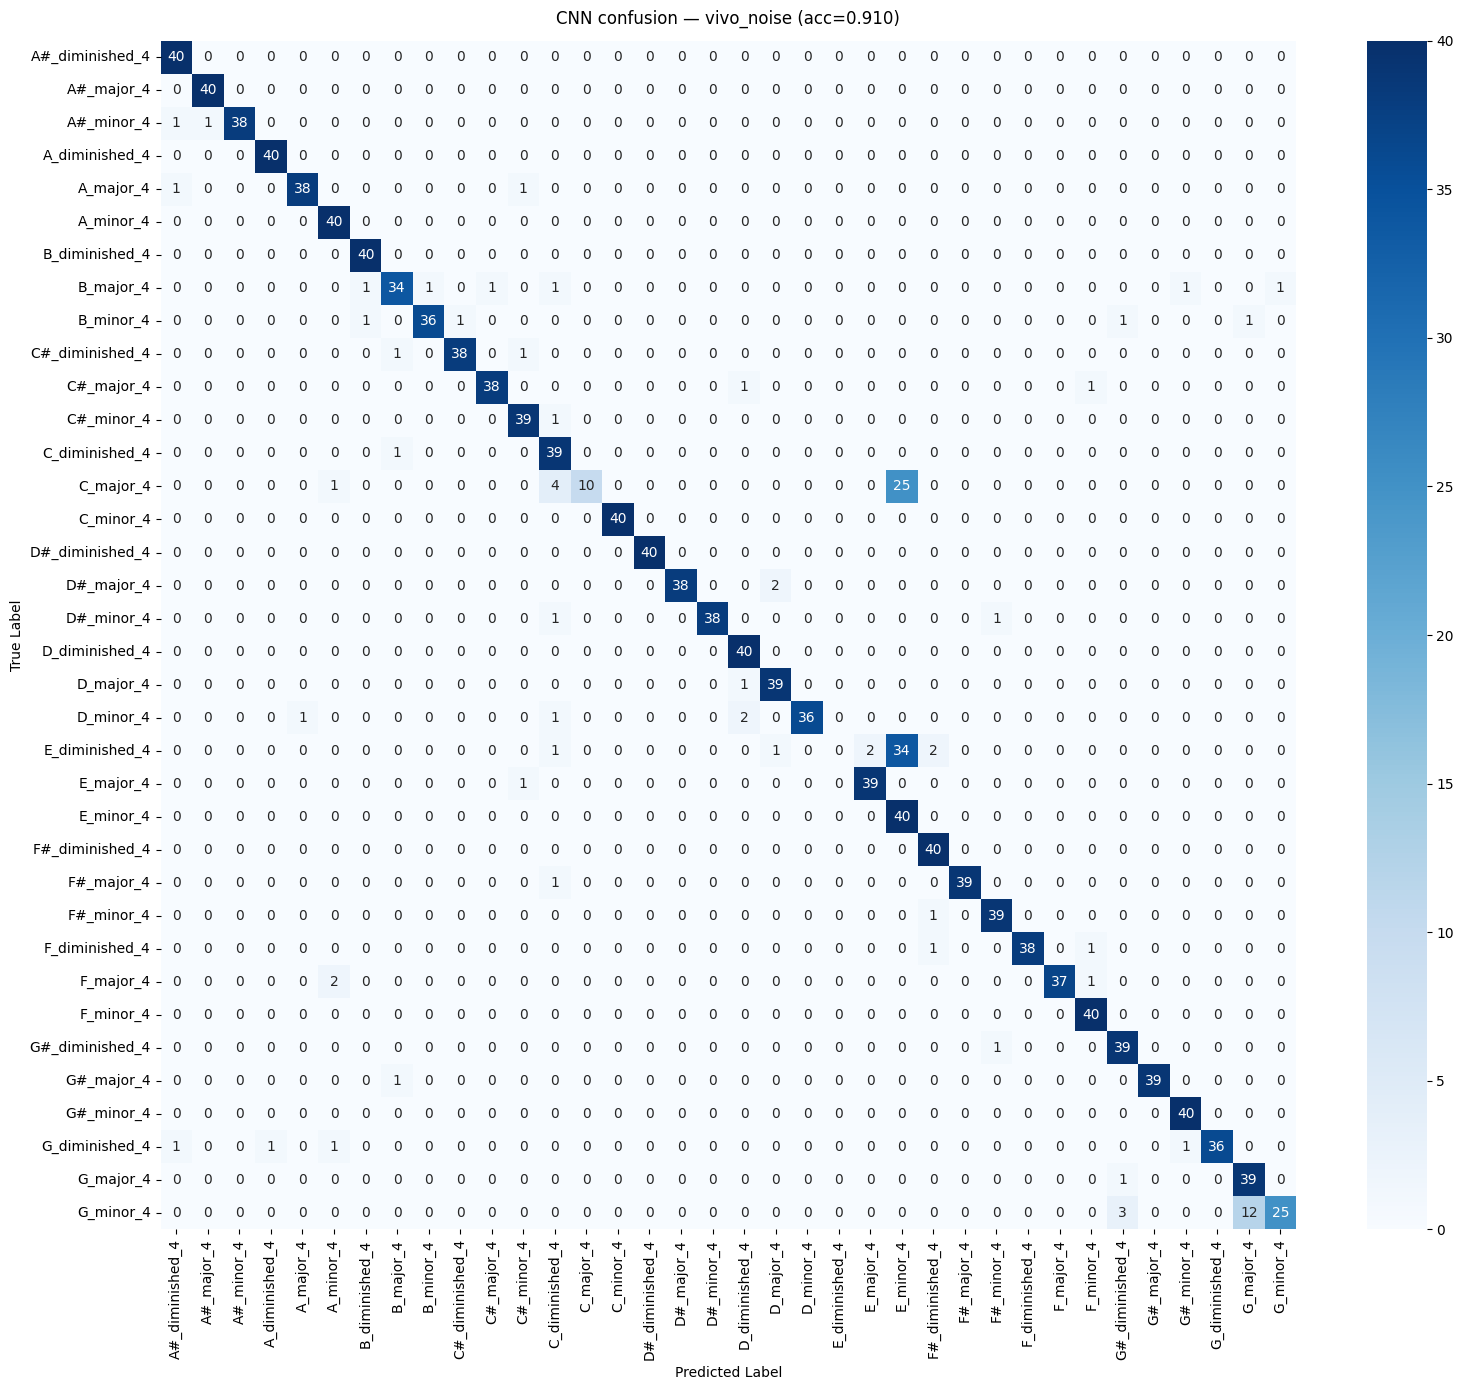

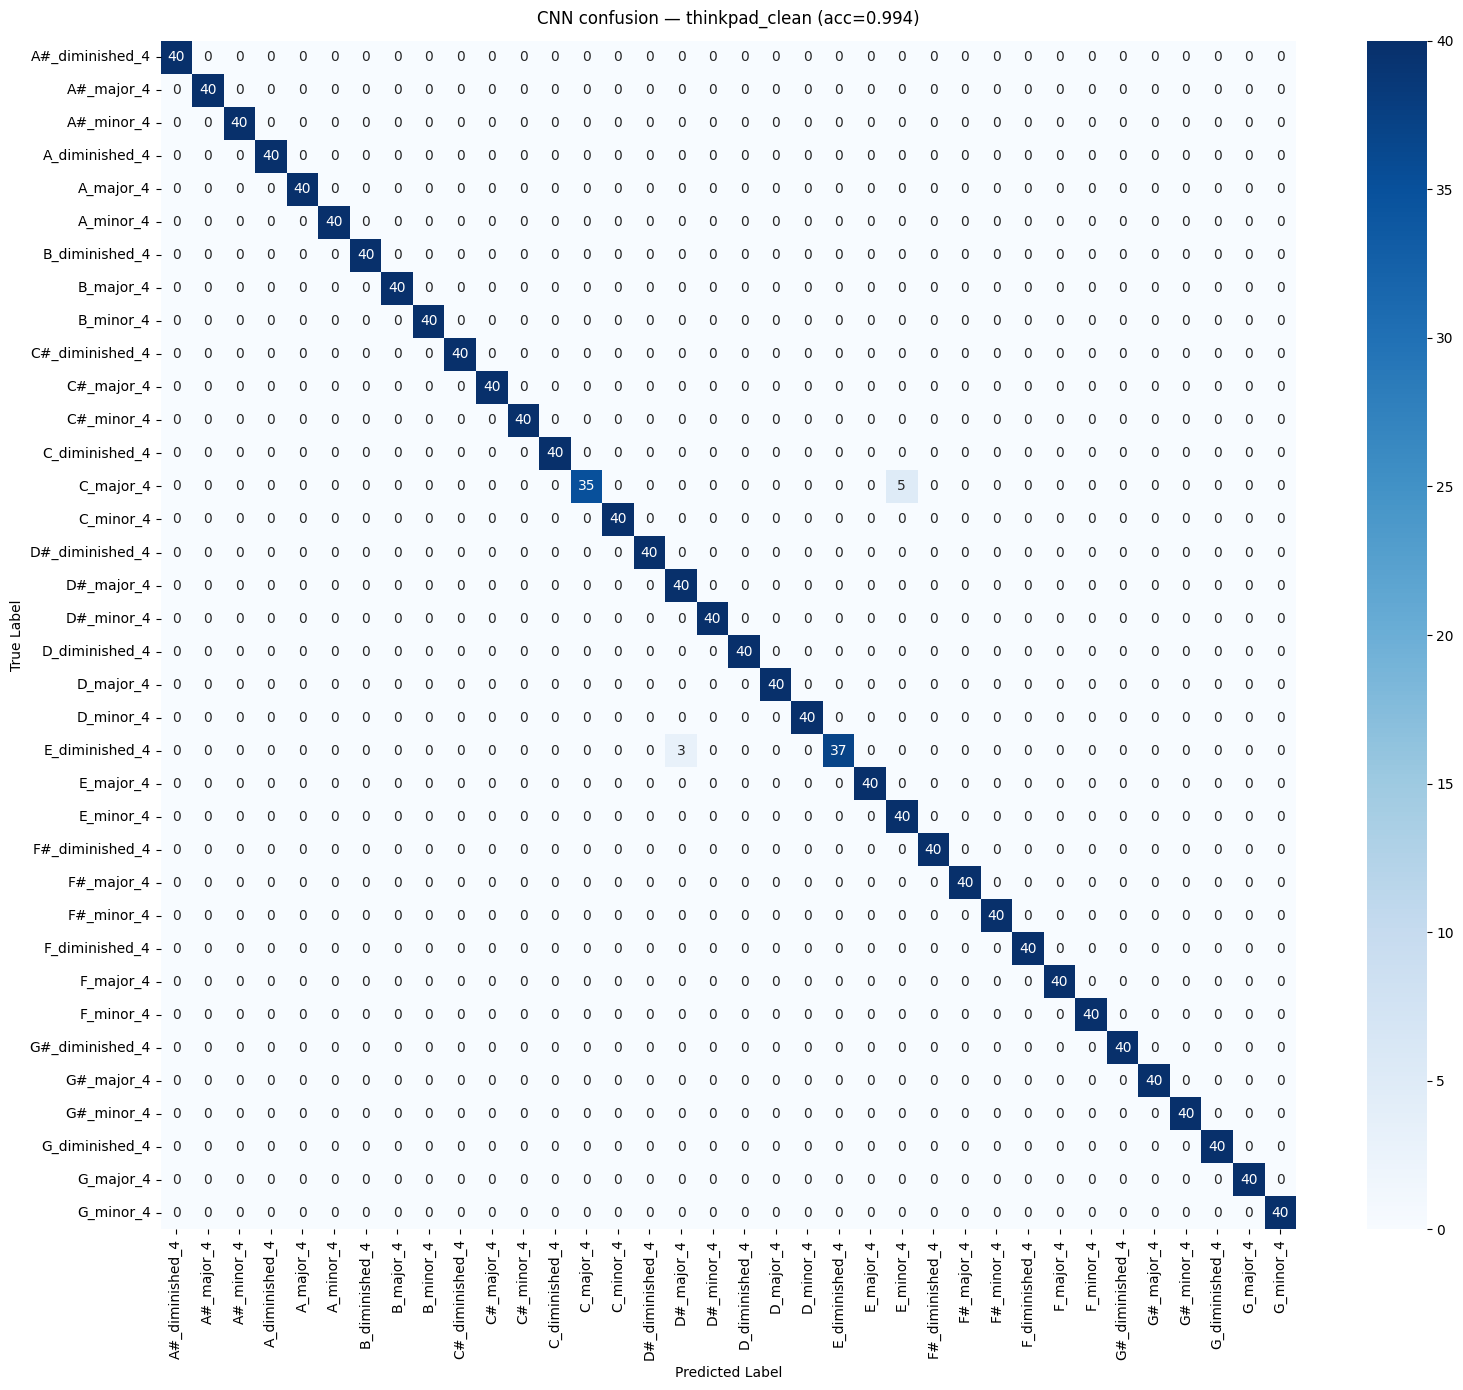

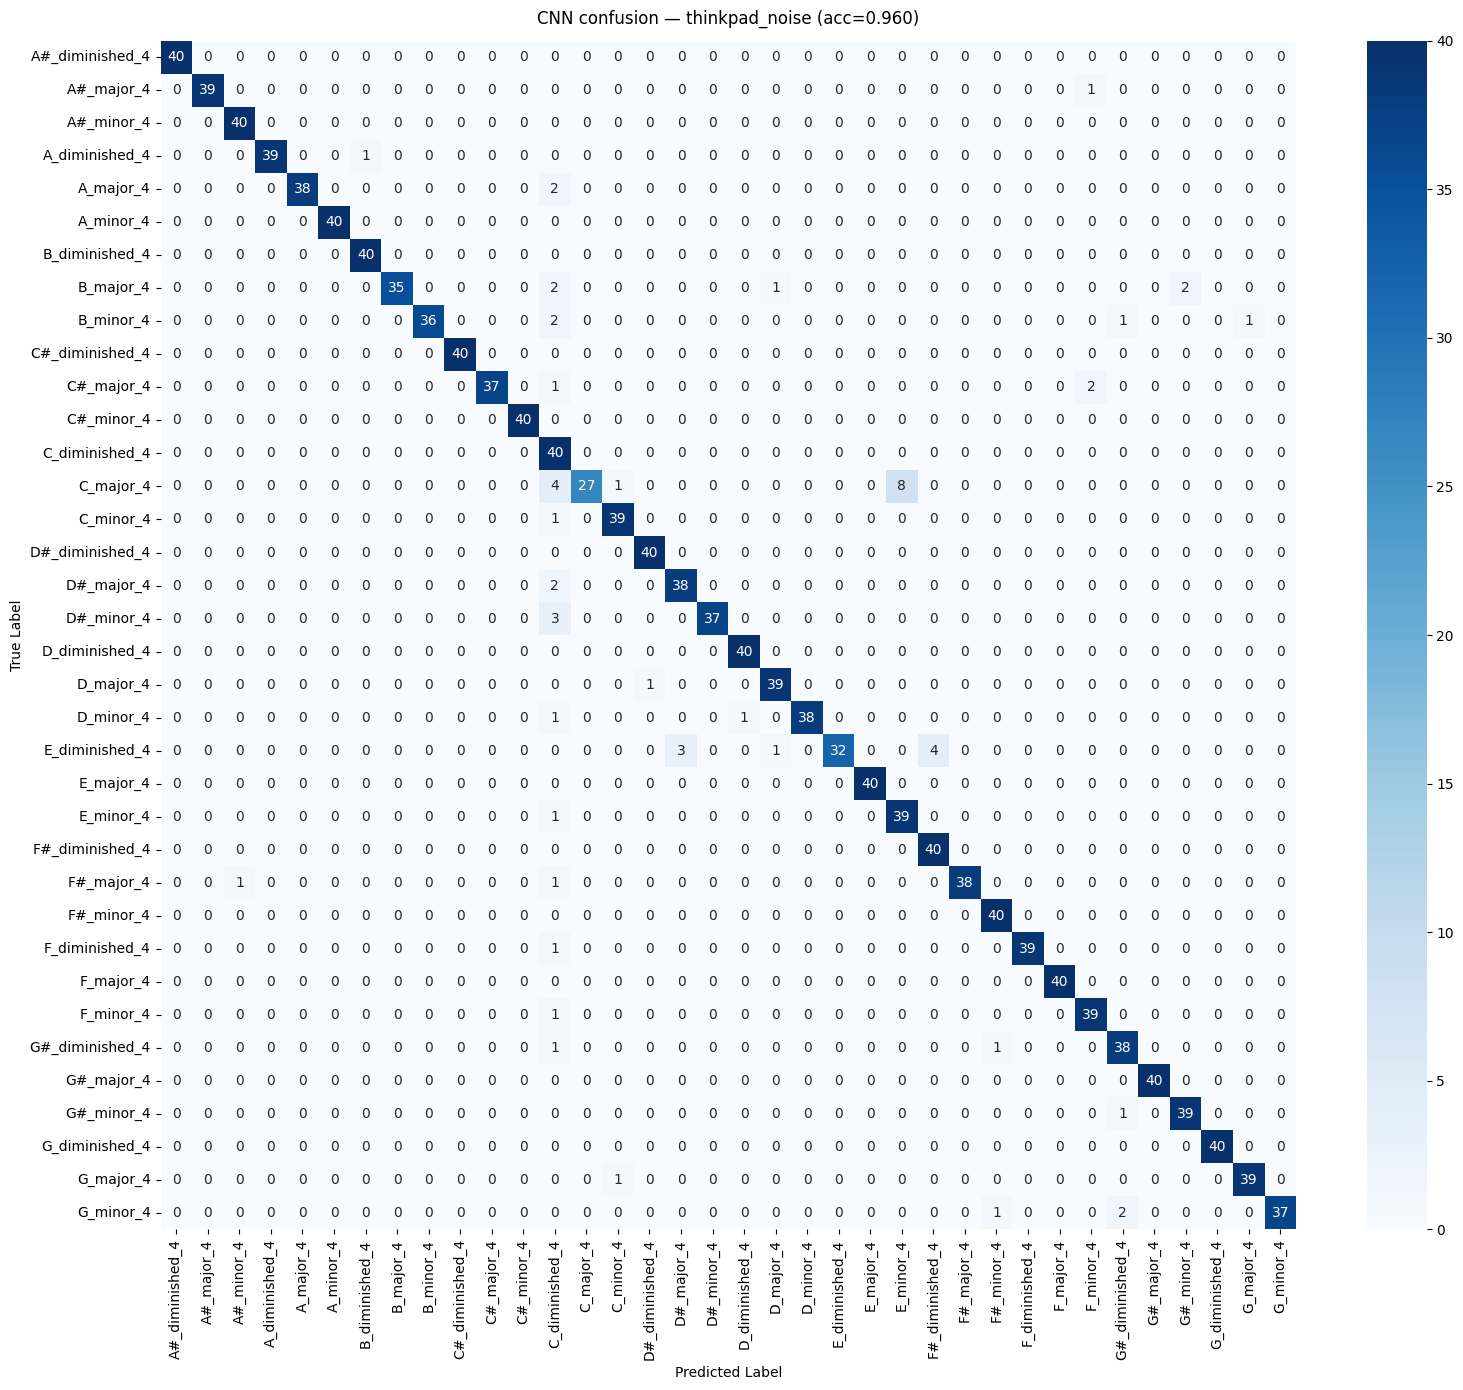

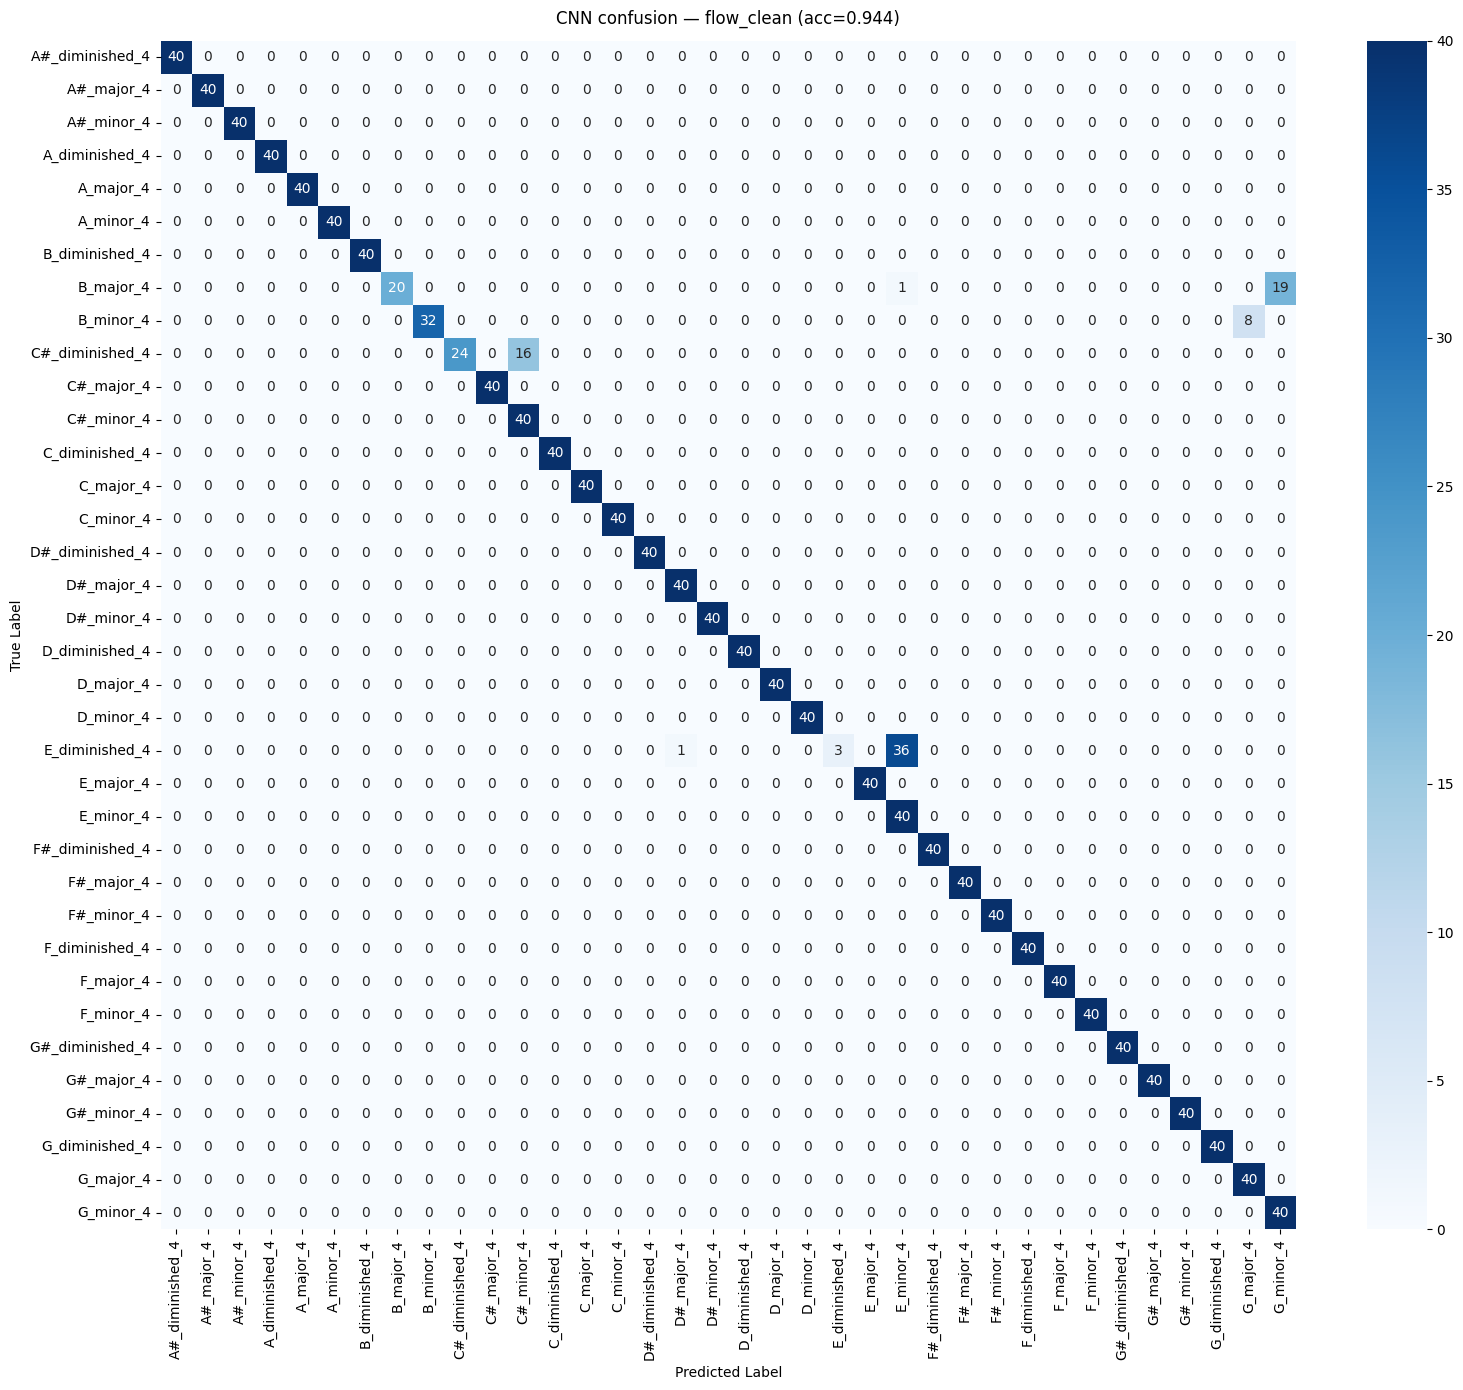

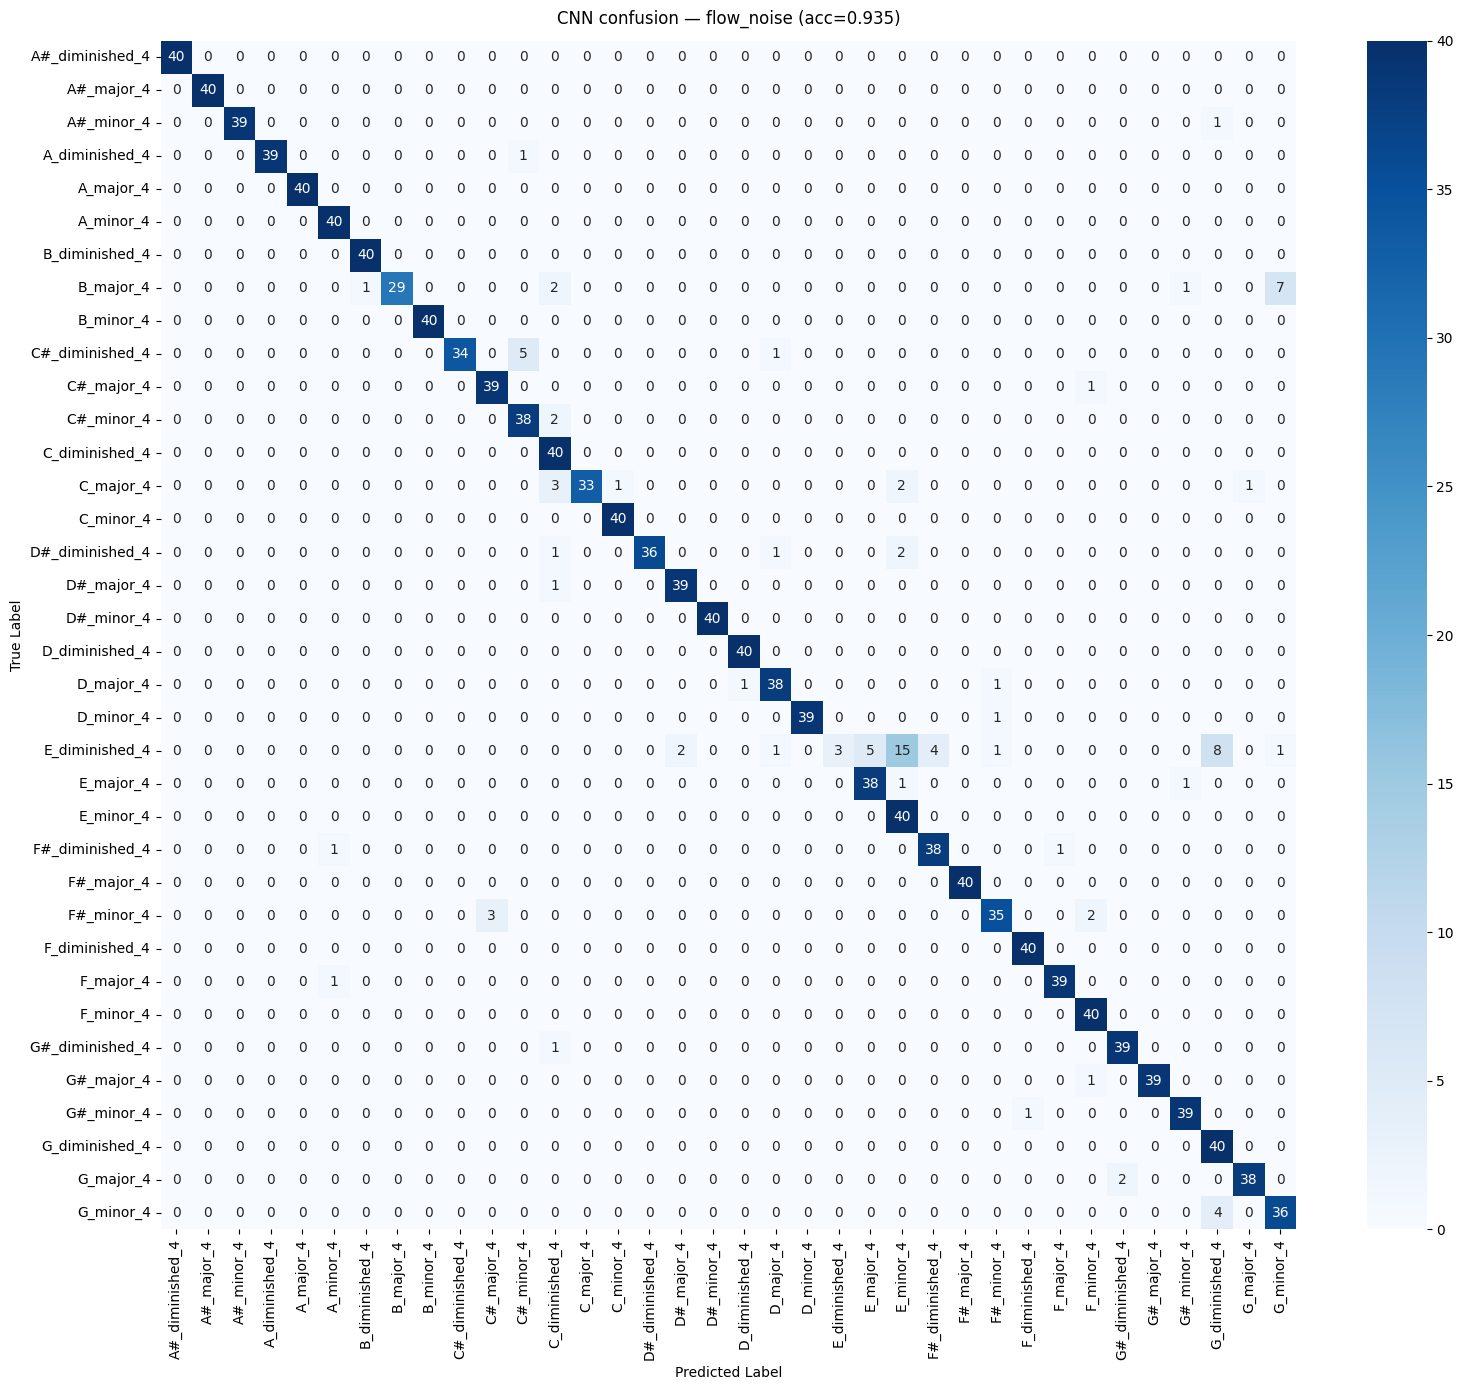

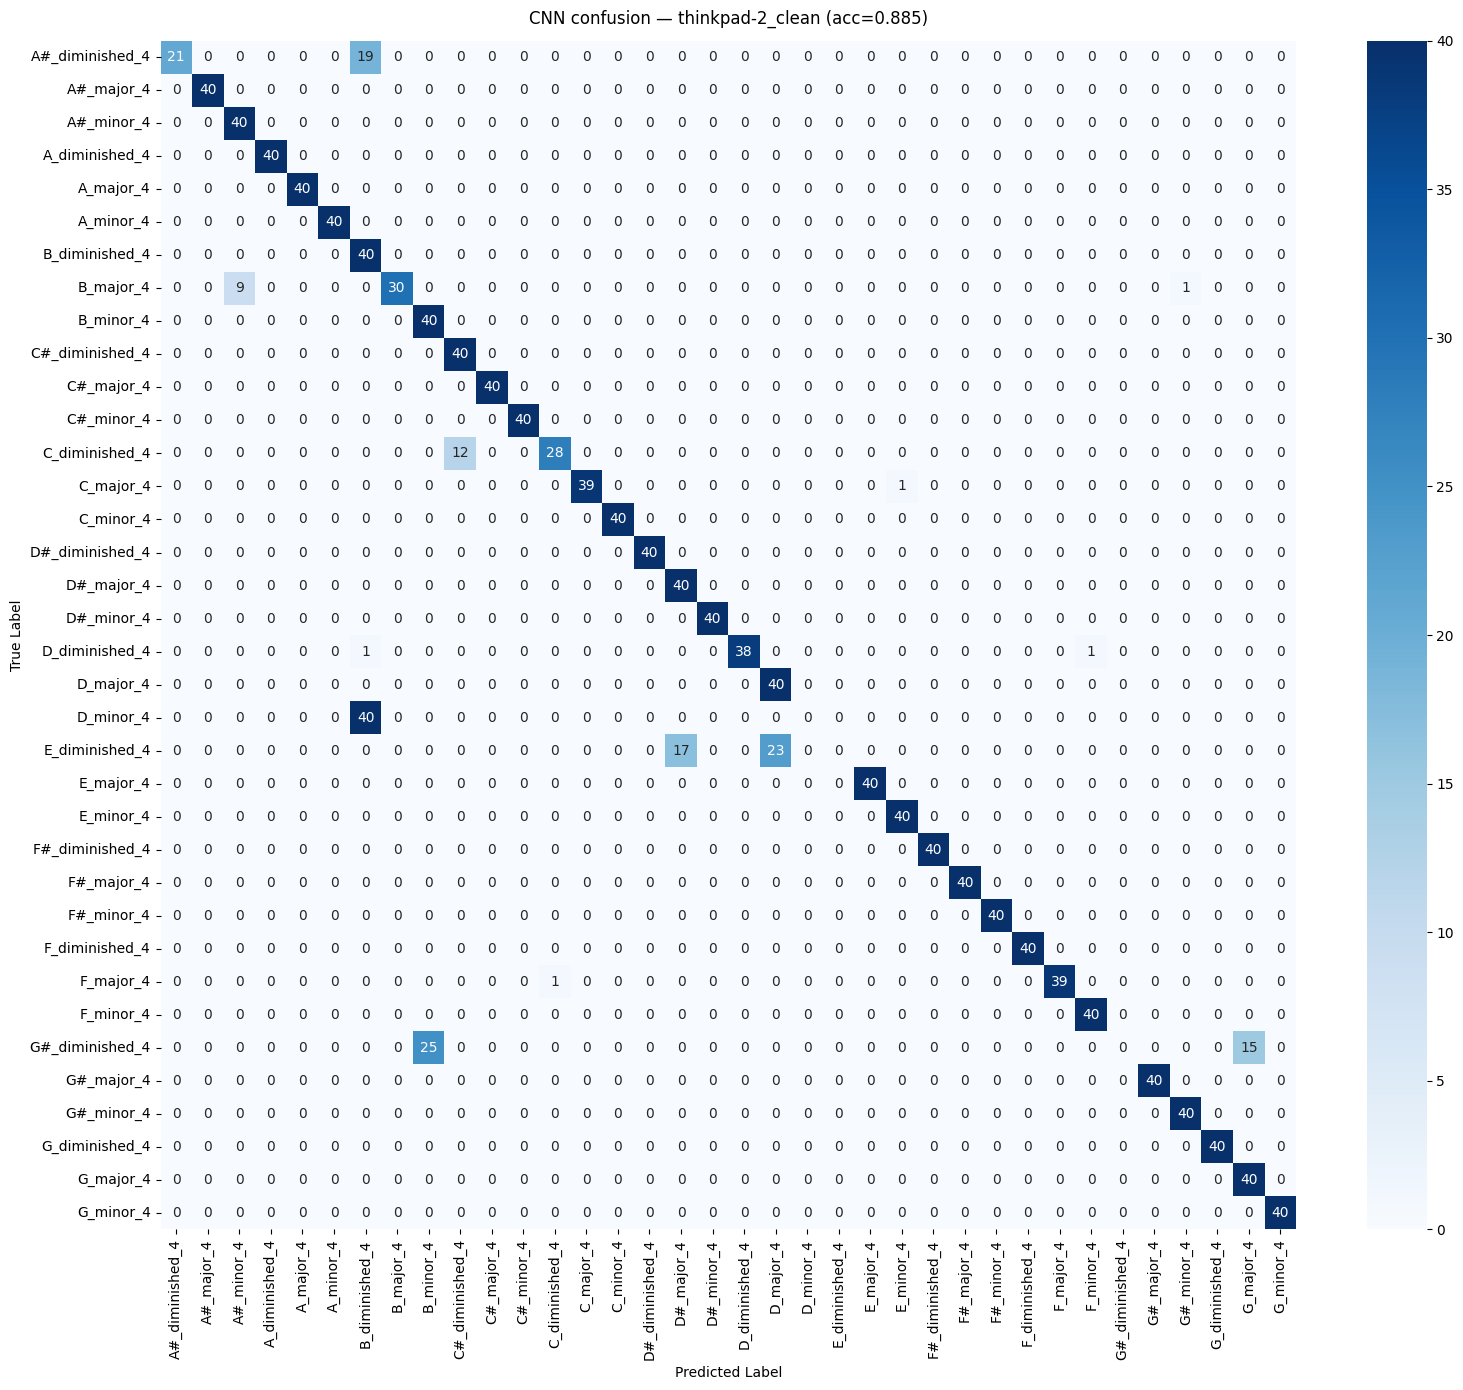

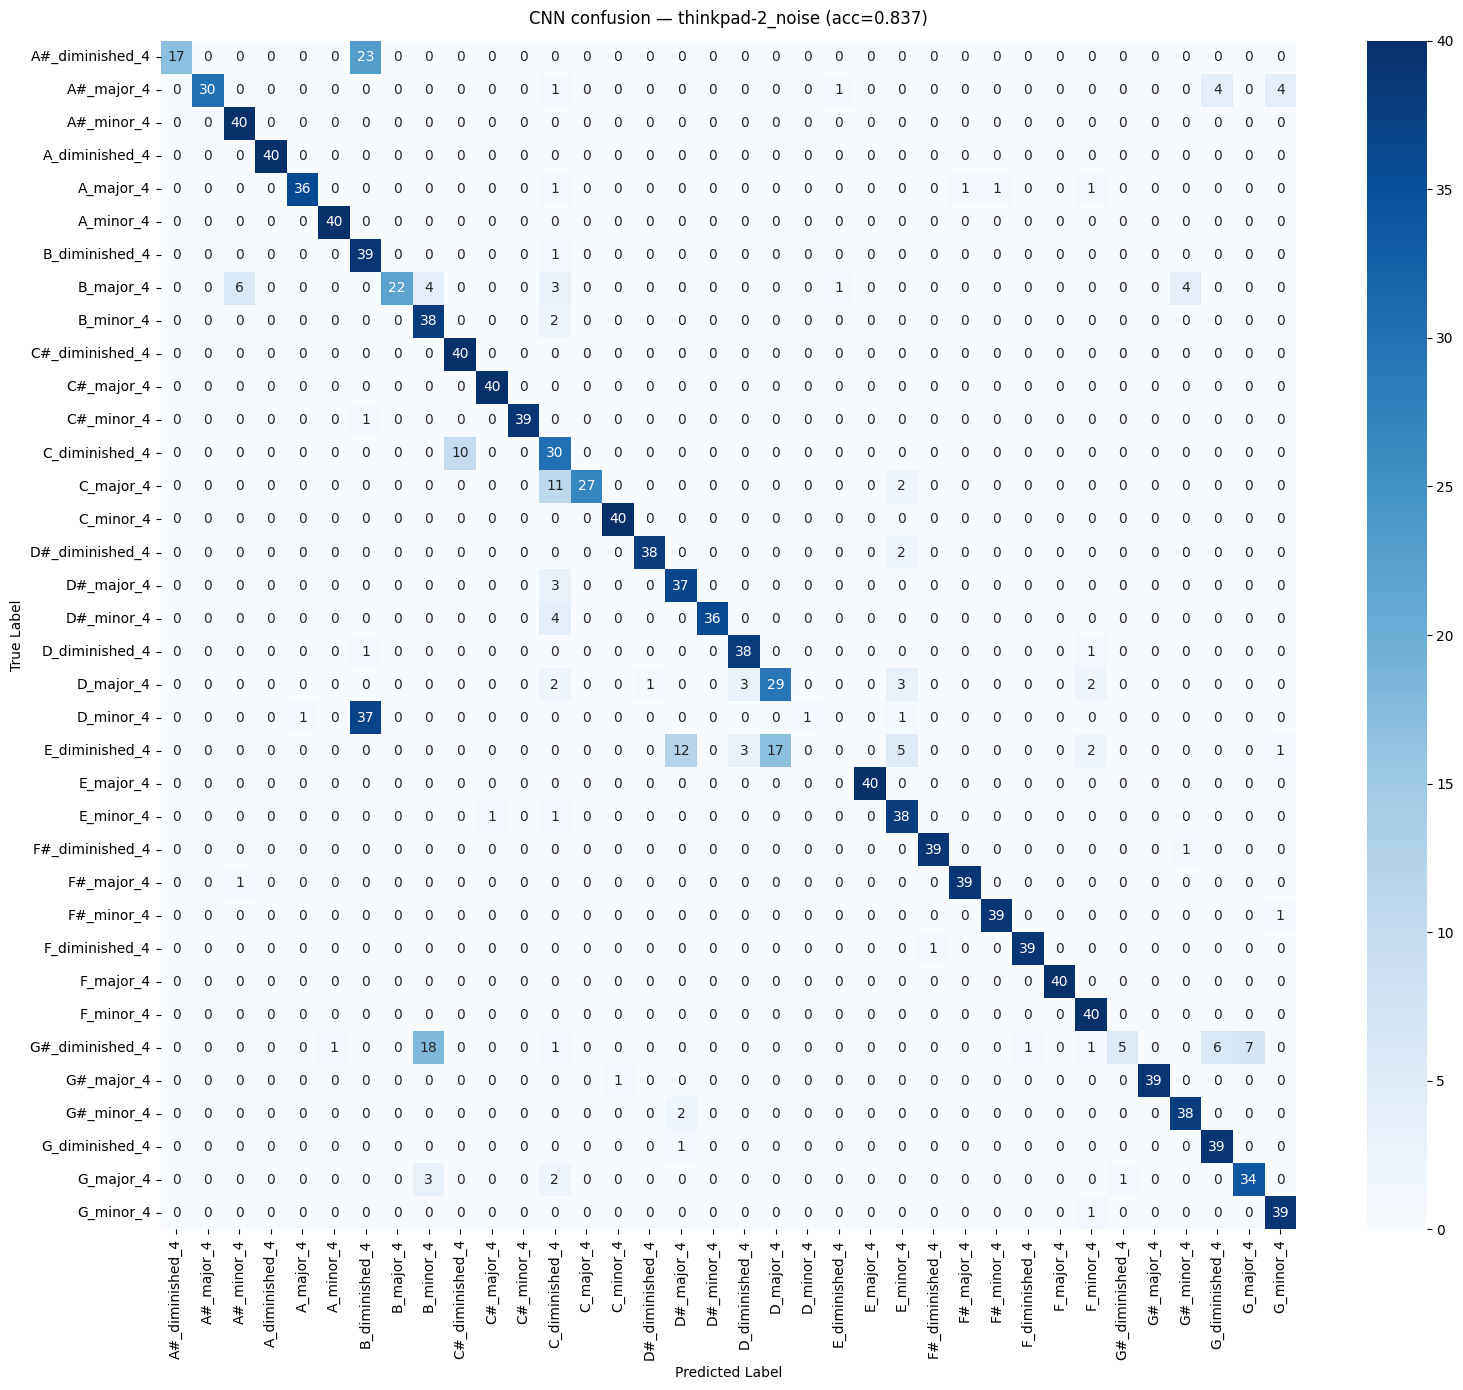

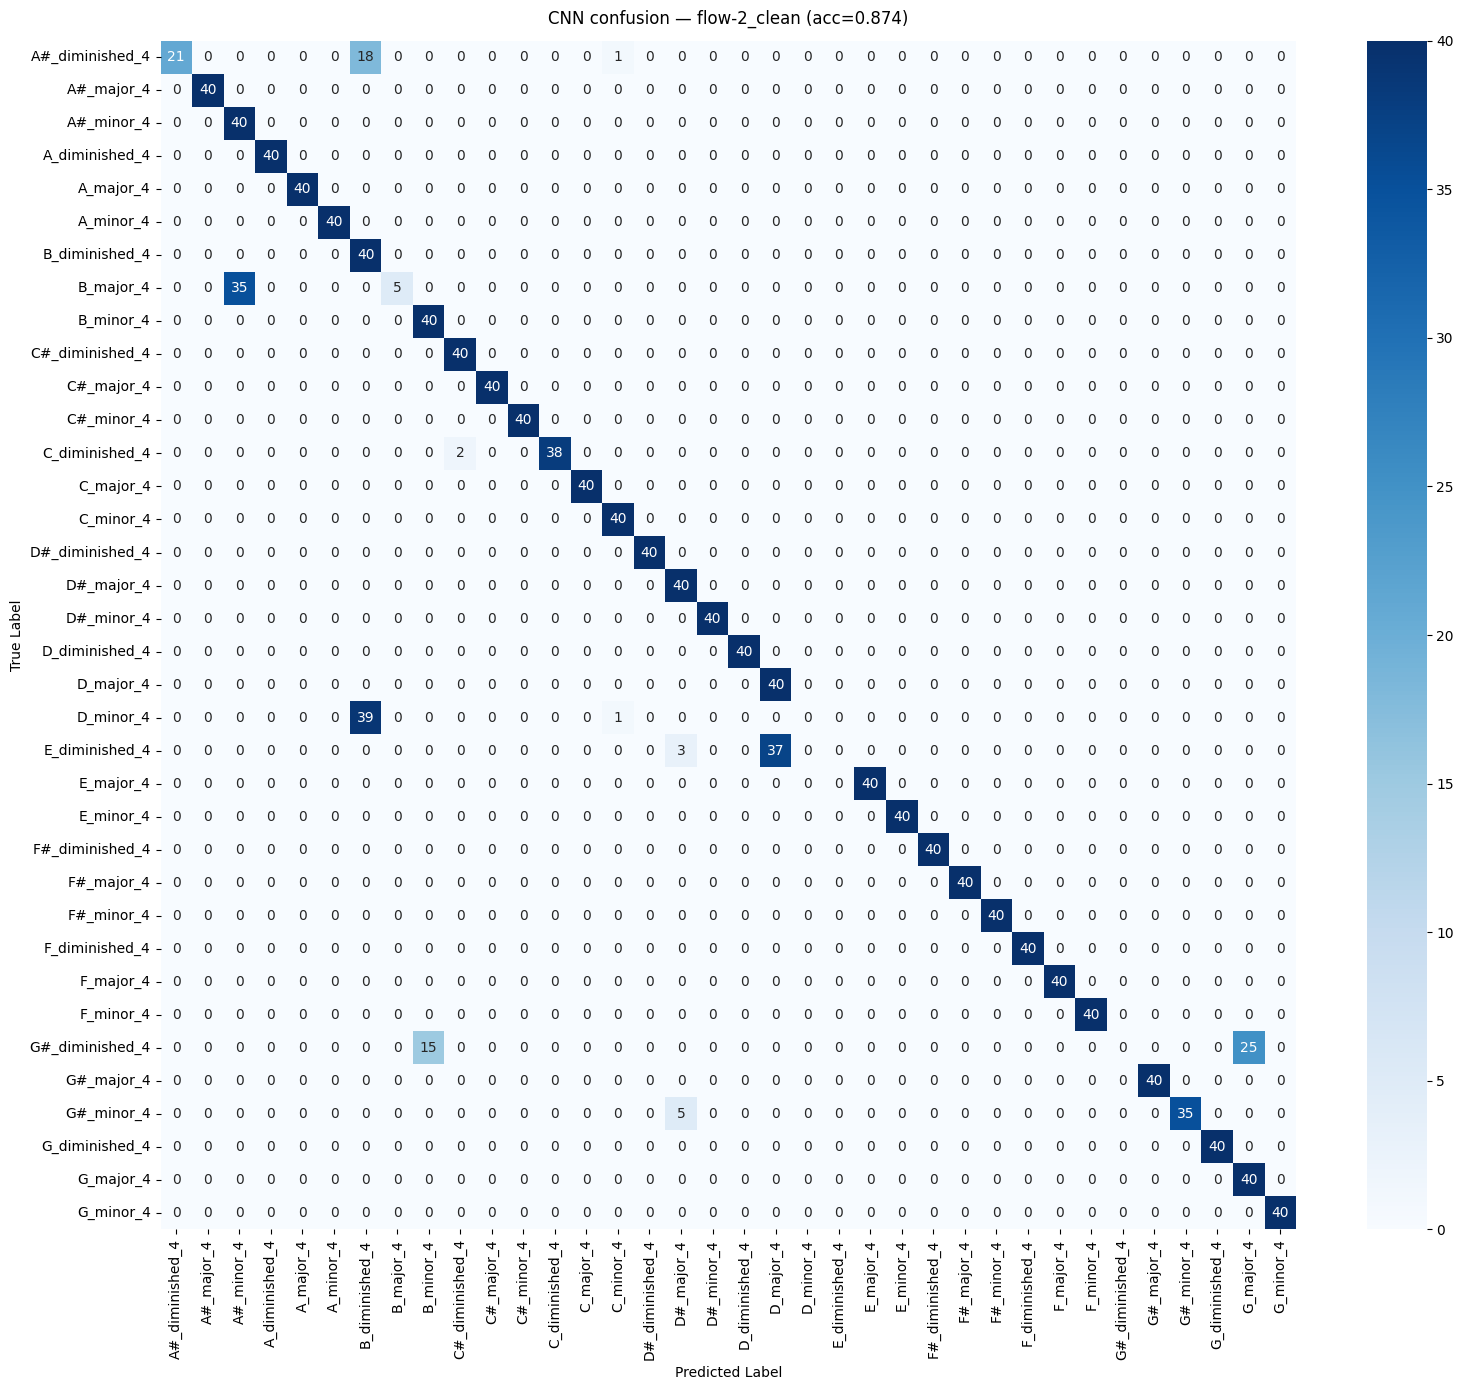

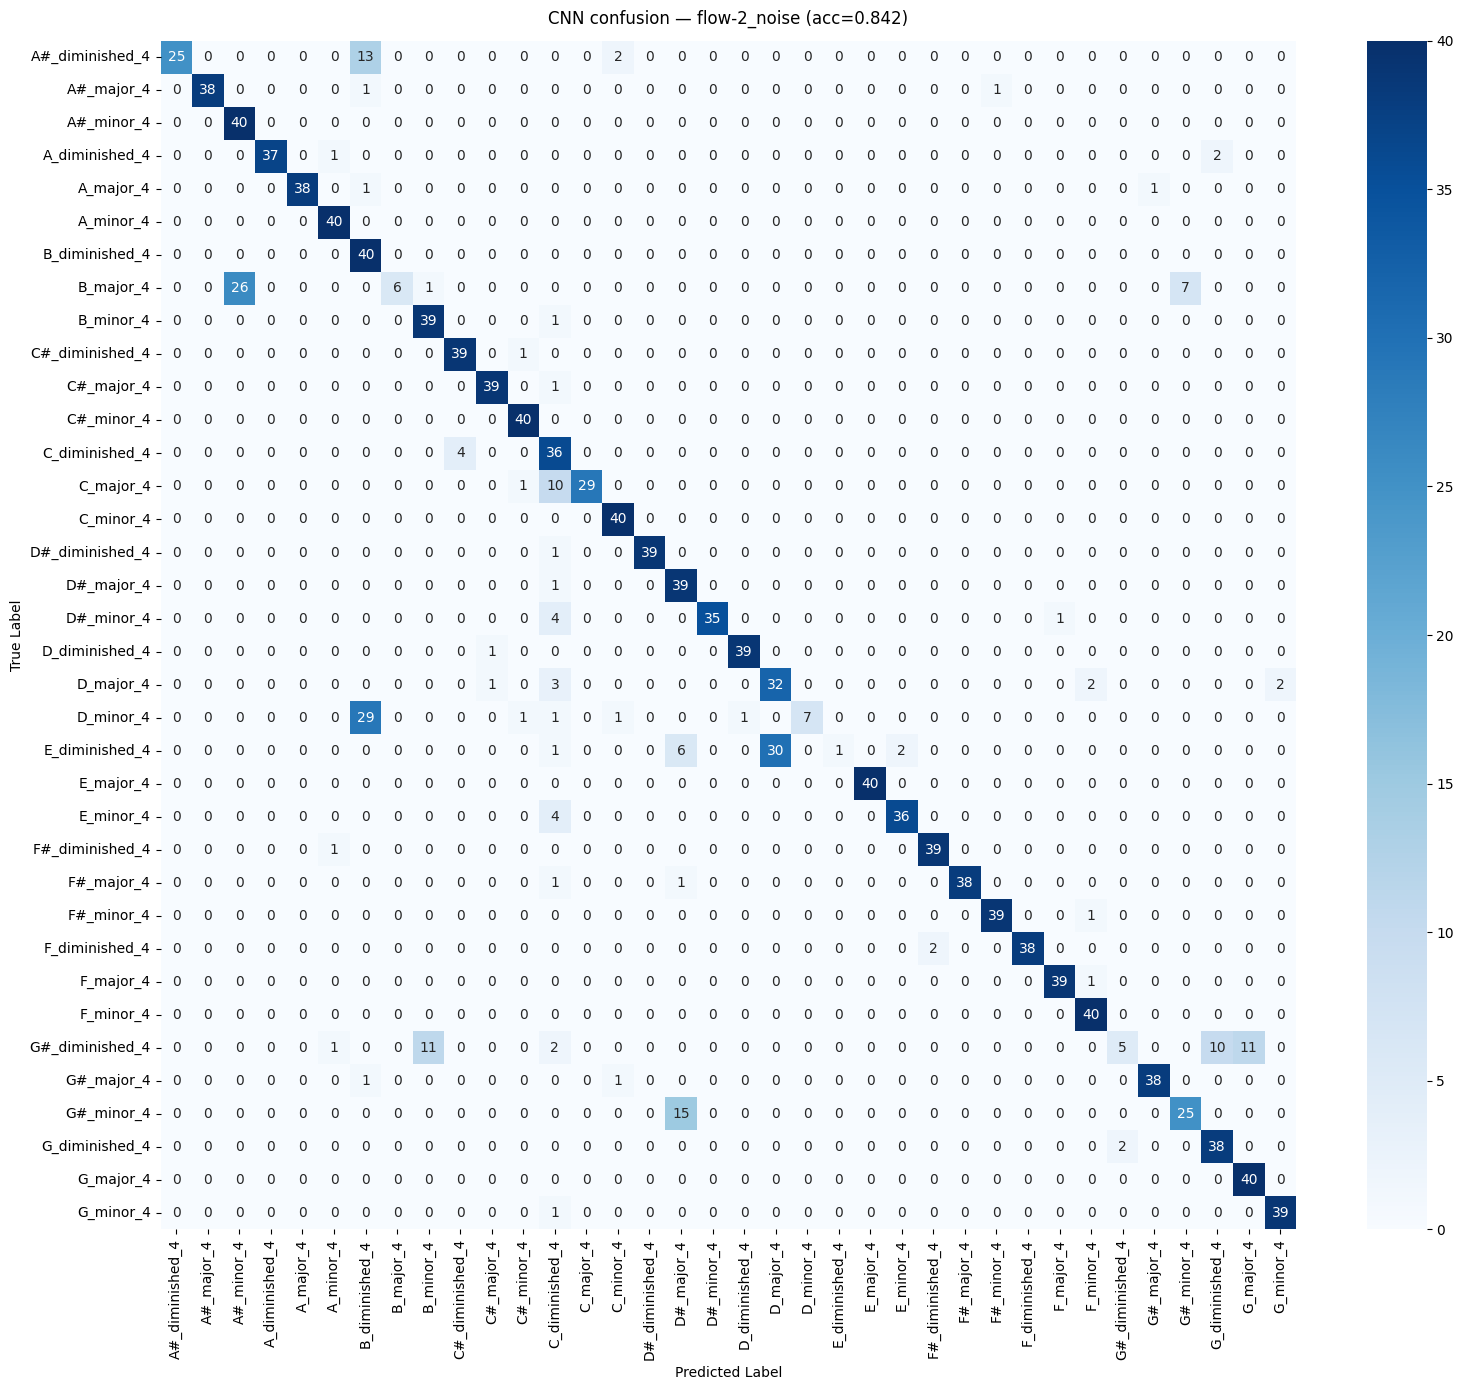

,name,domain,variant,accuracy,csv,png
0,vivo_clean,vivo,clean,0.945833,cnn-compare-results/confusion/vivo_clean.csv,cnn-compare-results/confusion/vivo_clean.png
1,vivo_noise,vivo,noise,0.910417,cnn-compare-results/confusion/vivo_noise.csv,cnn-compare-results/confusion/vivo_noise.png
2,thinkpad_clean,thinkpad,clean,0.994444,cnn-compare-results/confusion/thinkpad_clean.csv,cnn-compare-results/confusion/thinkpad_clean.png
3,thinkpad_noise,thinkpad,noise,0.959722,cnn-compare-results/confusion/thinkpad_noise.csv,cnn-compare-results/confusion/thinkpad_noise.png
4,flow_clean,flow,clean,0.943750,cnn-compare-results/confusion/flow_clean.csv,cnn-compare-results/confusion/flow_clean.png
5,flow_noise,flow,noise,0.935417,cnn-compare-results/confusion/flow_noise.csv,cnn-compare-results/confusion/flow_noise.png
6,thinkpad-2_clean,thinkpad-2,clean,0.885417,cnn-compare-results/confusion/thinkpad-2_clean...,cnn-compare-results/confusion/thinkpad-2_clean...
7,thinkpad-2_noise,thinkpad-2,noise,0.836806,cnn-compare-results/confusion/thinkpad-2_noise...,cnn-compare-results/confusion/thinkpad-2_noise...
8,flow-2_clean,flow-2,clean,0.874306,cnn-compare-results/confusion/flow-2_clean.csv,cnn-compare-results/confusion/flow-2_clean.png
9,flow-2_noise,flow-2,noise,0.841667,cnn-compare-results/confusion/flow-2_noise.csv,cnn-compare-results/confusion/flow-2_noise.png


In [8]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

CM_DIR = path.join(RESULTS_DIR, "confusion")
makedirs(CM_DIR, exist_ok=True)

cm_rows = []
for spec in EVAL_SETS:
    name = spec["name"]
    cpath = cache_path(name)
    if not path.isfile(cpath):
        continue
    cached = np.load(cpath, allow_pickle=True)
    y_true = cached["y_true"]
    y_pred = cached["y_pred"]
    class_names = cached["class_names"].astype(str)

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    csv_path = path.join(CM_DIR, f"{name}.csv")
    png_path = path.join(CM_DIR, f"{name}.png")
    cm_df.to_csv(csv_path)

    fig, ax = plt.subplots(figsize=(16, 14))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    acc = float(summary_df.loc[summary_df["name"] == name, "accuracy"].iloc[0])
    ax.set_title(
        f"CNN confusion — {name} (acc={acc:.3f})",
        pad=12,
    )
    fig.tight_layout()
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()

    cm_rows.append({
        "name": name,
        "domain": spec["domain"],
        "variant": spec["variant"],
        "accuracy": acc,
        "csv": csv_path,
        "png": png_path,
    })

display(pd.DataFrame(cm_rows))